# Task 1C — Feature Engineering

**Goal:** transform the cleaned daily dataset (from 1B) into two prediction-ready datasets:

1. **Tabular** (`features_tabular.csv`) — one row per prediction instance, flat feature vector for Random Forest (2A) and LightGBM (Task 4)
2. **Sequential** (`features_sequential.npz`) — 3D tensor (instances × 7 days × channels) for 1D CNN (2A, Task 4)

**Target:** next-day mean mood.

**Window size:** 7 days — justified by 1A's ACF (all 7 lags significant) and PACF (lag-3+ carry no direct signal → rolling summaries preferred over raw lags).


In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import save_figure
from src.features import (
    enrich_daily, build_tabular_dataset, build_sequential_dataset,
    TABULAR_FEATURE_COLS, CNN_CHANNELS,
)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

cleaned = pd.read_csv('../data/processed/cleaned.csv')
long_mood = pd.read_csv('../data/processed/cleaned_long_mood.csv')

print(f'Cleaned daily: {cleaned.shape[0]} rows × {cleaned.shape[1]} cols')
print(f'Long mood readings: {long_mood.shape[0]} rows')


Cleaned daily: 1973 rows × 26 cols
Long mood readings: 5641 rows


---
## 1. Filter February

1A showed February has systematic missingness across 13 variables (three distinct coverage groups — §3 cells 17–18). The 1B feasibility audit confirmed all 27 users retain ≥30 days after dropping February. We filter it here so feature windows are not contaminated by the ramp-up period.


In [2]:
cleaned['date'] = pd.to_datetime(cleaned['date'])
n_before = len(cleaned)
n_feb = (cleaned['date'].dt.month == 2).sum()
print(f'Rows before Feb filter: {n_before}')
print(f'February rows removed:  {n_feb}')
print(f'Rows after:             {n_before - n_feb}')


Rows before Feb filter: 1973
February rows removed:  240
Rows after:             1733


---
## 2. Feature enrichment pipeline

The `enrich_daily()` function applies the full pipeline in order:

1. **Drop February** (if enabled)
2. **Reindex to continuous calendar** — fills 181 absent calendar days so rolling/lag computations align with calendar time; short gaps (≤3 days) are linearly interpolated, long gaps flagged
3. **Time-of-day features** — `mood_morning` (readings before noon), `mood_evening` (readings after 18:00) from the raw timestamped readings
4. **Log transforms** — `log(1+x)` for all sensor/appCat columns; grouped appCats for CNN (social+comm, entertainment+game, other)
5. **Calendar features** — `is_weekend`, `day_of_week`
6. **Per-user baseline** — `user_mood_mean`, `user_mood_std` (computed on non-gap rows; leakage caveat — must be recomputed per training fold in 2A/4)
7. **Lag features** — gap-aware `mood_lag1`, `mood_lag2`, `valence_lag1` (only valid when calendar gap = nominal lag)
8. **Rolling 7-day features** — mean/std/min/max/trend for mood; mean/std for valence, activity, screen
9. **Target** — next calendar day's mood mean (shift by −1, gap-aware)


In [3]:
enriched = enrich_daily(cleaned, long_mood, window=7, drop_february=True)

print(f'Enriched shape: {enriched.shape[0]} rows × {enriched.shape[1]} cols')
print(f'Users: {enriched["id"].nunique()}')
print(f'Date range: {enriched["date"].min().date()} to {enriched["date"].max().date()}')
print(f'gap_flag=1 rows: {(enriched["gap_flag"]==1).sum()}')
print(f'Rows with valid target: {enriched["target"].notna().sum()}')
print()
print('Columns added:')
new_cols = sorted(set(enriched.columns) - set(cleaned.columns))
for i in range(0, len(new_cols), 5):
    print('  ' + ', '.join(new_cols[i:i+5]))


Enriched shape: 1847 rows × 65 cols
Users: 27
Date range: 2014-03-01 to 2014-06-09
gap_flag=1 rows: 538
Rows with valid target: 1308

Columns added:
  activity_rmean_7d, activity_rstd_7d, appCat_leisure, appCat_other, appCat_social_comm
  day_of_week, is_weekend, log1p_appCat.builtin, log1p_appCat.communication, log1p_appCat.entertainment
  log1p_appCat.finance, log1p_appCat.game, log1p_appCat.office, log1p_appCat.other, log1p_appCat.social
  log1p_appCat.travel, log1p_appCat.unknown, log1p_appCat.utilities, log1p_appCat.weather, log1p_call
  log1p_screen, log1p_sms, mood_evening, mood_lag1, mood_lag2
  mood_morning, mood_rmax_7d, mood_rmean_7d, mood_rmin_7d, mood_rstd_7d
  mood_rtrend_7d, screen_rmean_7d, screen_rstd_7d, target, user_mood_mean
  user_mood_std, valence_lag1, valence_rmean_7d, valence_rstd_7d


---
## 3. Feature inspection


Saved: figures/1c_mood_time_of_day.png


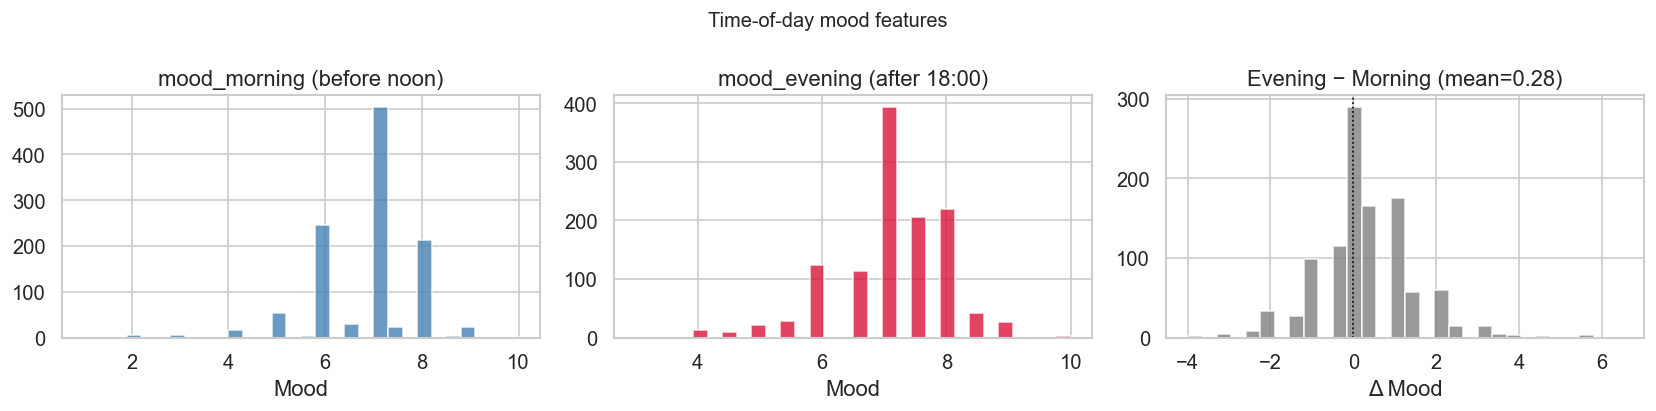

mood_morning coverage: 86.4% of non-gap days
mood_evening coverage: 91.8% of non-gap days


In [4]:
# Within-day mood texture
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
non_gap = enriched[enriched['gap_flag'] == 0]

axes[0].hist(non_gap['mood_morning'].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('mood_morning (before noon)')
axes[0].set_xlabel('Mood')

axes[1].hist(non_gap['mood_evening'].dropna(), bins=30, color='crimson', edgecolor='white', alpha=0.8)
axes[1].set_title('mood_evening (after 18:00)')
axes[1].set_xlabel('Mood')

diff = (non_gap['mood_evening'] - non_gap['mood_morning']).dropna()
axes[2].hist(diff, bins=30, color='grey', edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='black', linewidth=1, linestyle=':')
axes[2].set_title(f'Evening − Morning (mean={diff.mean():.2f})')
axes[2].set_xlabel('Δ Mood')

plt.suptitle('Time-of-day mood features', fontsize=12)
plt.tight_layout()
save_figure('1c_mood_time_of_day.png')
plt.show()

print(f'mood_morning coverage: {non_gap["mood_morning"].notna().mean():.1%} of non-gap days')
print(f'mood_evening coverage: {non_gap["mood_evening"].notna().mean():.1%} of non-gap days')


Saved: figures/1c_rolling_features.png


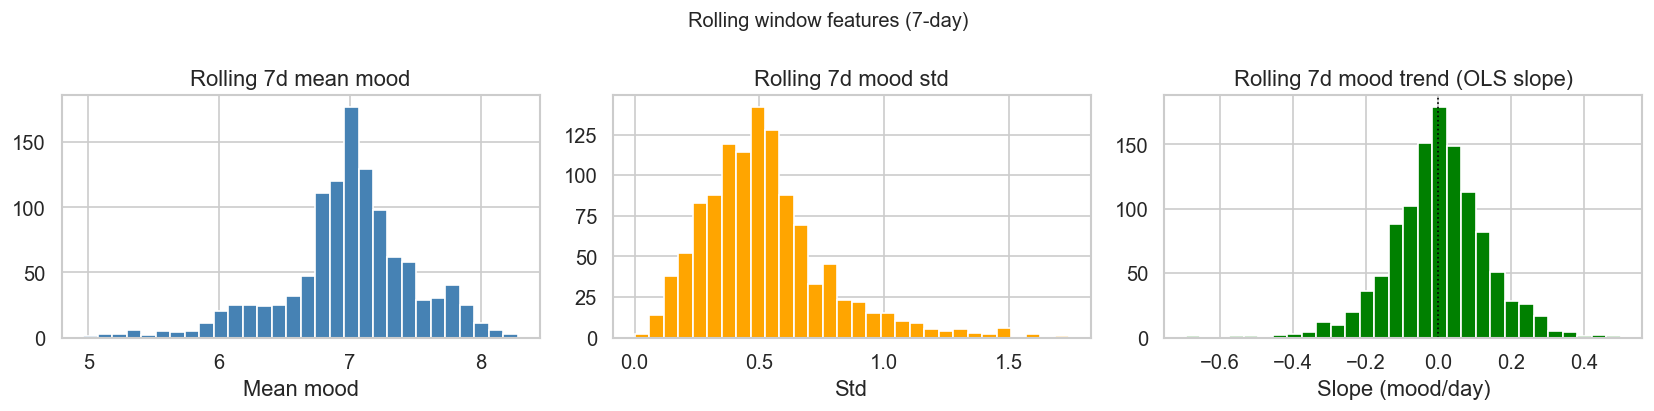

In [5]:
# Rolling features: distribution of mood trend (slope)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

axes[0].hist(non_gap['mood_rmean_7d'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Rolling 7d mean mood')
axes[0].set_xlabel('Mean mood')

axes[1].hist(non_gap['mood_rstd_7d'].dropna(), bins=30, color='orange', edgecolor='white')
axes[1].set_title('Rolling 7d mood std')
axes[1].set_xlabel('Std')

axes[2].hist(non_gap['mood_rtrend_7d'].dropna(), bins=30, color='green', edgecolor='white')
axes[2].axvline(0, color='black', linewidth=1, linestyle=':')
axes[2].set_title('Rolling 7d mood trend (OLS slope)')
axes[2].set_xlabel('Slope (mood/day)')

plt.suptitle('Rolling window features (7-day)', fontsize=12)
plt.tight_layout()
save_figure('1c_rolling_features.png')
plt.show()


---
## 4. Build tabular dataset

Valid prediction instances must satisfy:
- Target (next-day mood) exists
- All rolling features defined (requires 7 consecutive days of history)
- No `gap_flag=1` in the preceding 7-day window


In [6]:
tabular = build_tabular_dataset(enriched, window=7)

print(f'Tabular dataset: {tabular.shape[0]} instances × {tabular.shape[1]} columns')
print(f'Users represented: {tabular["id"].nunique()}')
print(f'Features: {tabular.shape[1] - 3} (excl. id, date, target)')
print()
print('Feature columns:')
feat_cols = [c for c in tabular.columns if c not in ('id', 'date', 'target')]
for i in range(0, len(feat_cols), 4):
    print('  ' + ', '.join(feat_cols[i:i+4]))
print()
print(f'Instances per user:')
ipu = tabular.groupby('id').size()
print(f'  mean={ipu.mean():.1f}, min={ipu.min()}, max={ipu.max()}, total={ipu.sum()}')
print()
print('NaN audit (should be zero for most features):')
nan_counts = tabular[feat_cols].isna().sum()
has_nan = nan_counts[nan_counts > 0]
if len(has_nan):
    print(has_nan.to_string())
else:
    print('  No NaN in any feature column.')


Tabular dataset: 1037 instances × 46 columns
Users represented: 27
Features: 43 (excl. id, date, target)

Feature columns:
  mood, mood_std, mood_min, mood_max
  mood_count, circumplex.valence, circumplex.arousal, activity
  screen, call, sms, mood_morning
  mood_evening, is_weekend, day_of_week, mood_lag1
  mood_lag2, valence_lag1, mood_rmean_7d, mood_rstd_7d
  mood_rmin_7d, mood_rmax_7d, mood_rtrend_7d, valence_rmean_7d
  valence_rstd_7d, activity_rmean_7d, activity_rstd_7d, screen_rmean_7d
  screen_rstd_7d, user_mood_mean, user_mood_std, appCat.builtin
  appCat.communication, appCat.entertainment, appCat.finance, appCat.game
  appCat.office, appCat.other, appCat.social, appCat.travel
  appCat.unknown, appCat.utilities, appCat.weather

Instances per user:
  mean=38.4, min=24, max=50, total=1037

NaN audit (should be zero for most features):
mood_morning    120
mood_evening     71


---
## 5. Build sequential dataset (CNN input)

Each instance is a 2D matrix: 7 days × channels. Channels include mood summaries, valence, arousal, activity, log-screen, weekend flag, and grouped appCats.

The sequential dataset uses the **same validity criteria** as the tabular dataset (no gaps, valid target) so both datasets share the same set of prediction instances.


In [7]:
X, y, meta = build_sequential_dataset(enriched, window=7)

channels_used = [c for c in CNN_CHANNELS if c in enriched.columns]
print(f'Sequential dataset:')
print(f'  X shape: {X.shape}  (instances × window × channels)')
print(f'  y shape: {y.shape}')
print(f'  Users: {meta["id"].nunique()}')
print()
print(f'Channels ({len(channels_used)}):')
for i, ch in enumerate(channels_used):
    print(f'  [{i}] {ch}')
print()
print(f'Instance count matches tabular: {X.shape[0] == len(tabular)}')


Sequential dataset:
  X shape: (1037, 7, 12)  (instances × window × channels)
  y shape: (1037,)
  Users: 27

Channels (12):
  [0] mood
  [1] mood_std
  [2] mood_min
  [3] mood_max
  [4] circumplex.valence
  [5] circumplex.arousal
  [6] activity
  [7] log1p_screen
  [8] is_weekend
  [9] appCat_social_comm
  [10] appCat_leisure
  [11] appCat_other

Instance count matches tabular: True


---
## 6. Target inspection

The target is next-day mean mood. For Task 2A (classification), we need a binary threshold — computed as the median of the target distribution so classes are balanced by construction.


Saved: figures/1c_target_distribution.png


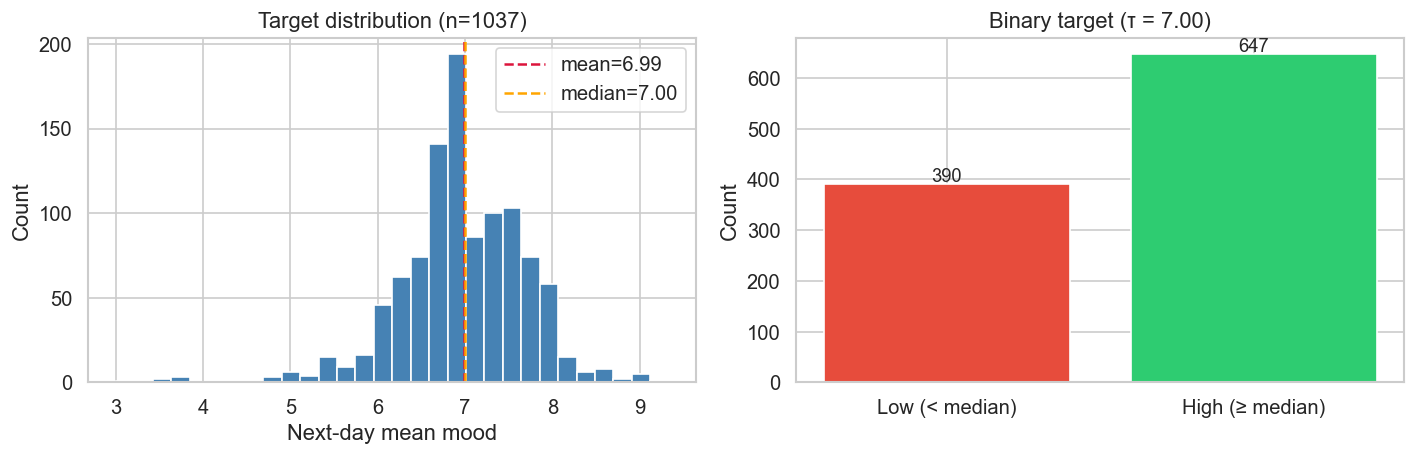

Classification threshold τ = median(target) = 7.000
Class balance: Low=390 (37.6%), High=647 (62.4%)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Regression target
axes[0].hist(tabular['target'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title(f'Target distribution (n={len(tabular)})')
axes[0].set_xlabel('Next-day mean mood')
axes[0].set_ylabel('Count')
axes[0].axvline(tabular['target'].mean(), color='crimson', linestyle='--', label=f'mean={tabular["target"].mean():.2f}')
axes[0].axvline(tabular['target'].median(), color='orange', linestyle='--', label=f'median={tabular["target"].median():.2f}')
axes[0].legend()

# Classification target
tau = tabular['target'].median()
tabular['target_class'] = (tabular['target'] >= tau).astype(int)
class_counts = tabular['target_class'].value_counts().sort_index()
axes[1].bar(['Low (< median)', 'High (≥ median)'], class_counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[1].set_title(f'Binary target (τ = {tau:.2f})')
axes[1].set_ylabel('Count')
for j, v in enumerate(class_counts.values):
    axes[1].text(j, v + 5, str(v), ha='center', fontsize=11)

plt.tight_layout()
save_figure('1c_target_distribution.png')
plt.show()

print(f'Classification threshold τ = median(target) = {tau:.3f}')
print(f'Class balance: Low={class_counts[0]} ({class_counts[0]/len(tabular):.1%}), '
      f'High={class_counts[1]} ({class_counts[1]/len(tabular):.1%})')
tabular = tabular.drop(columns=['target_class'])


---
## 7. Feature–target correlation

Top features by absolute Spearman correlation with the regression target. This helps confirm the 1A findings carry through to the engineered features and flags potential redundancy.


Saved: figures/1c_feature_target_correlation.png


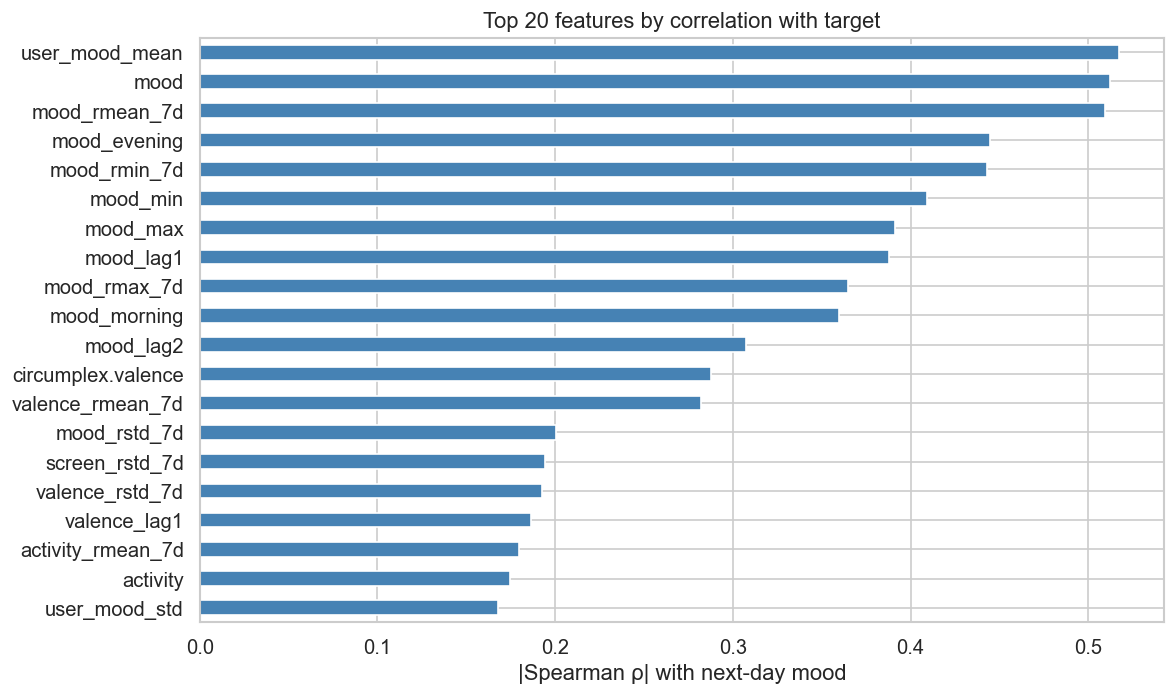

Top 10 features by |Spearman ρ| with target:
  user_mood_mean                  ρ = 0.517
  mood                            ρ = 0.512
  mood_rmean_7d                   ρ = 0.510
  mood_evening                    ρ = 0.444
  mood_rmin_7d                    ρ = 0.443
  mood_min                        ρ = 0.409
  mood_max                        ρ = 0.391
  mood_lag1                       ρ = 0.388
  mood_rmax_7d                    ρ = 0.365
  mood_morning                    ρ = 0.360


In [9]:
feat_cols = [c for c in tabular.columns if c not in ('id', 'date', 'target')]
corrs = tabular[feat_cols + ['target']].corr(method='spearman')['target'].drop('target').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top = corrs.head(20)
top.plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('|Spearman ρ| with next-day mood')
ax.set_title('Top 20 features by correlation with target')
plt.tight_layout()
save_figure('1c_feature_target_correlation.png')
plt.show()

print('Top 10 features by |Spearman ρ| with target:')
for feat, r in corrs.head(10).items():
    print(f'  {feat:30s}  ρ = {r:.3f}')


---
## 8. Save outputs


In [10]:
import os
os.makedirs('../data/processed', exist_ok=True)

tabular.to_csv('../data/processed/features_tabular.csv', index=False)
print(f'Saved: data/processed/features_tabular.csv ({tabular.shape[0]} × {tabular.shape[1]})')

np.savez(
    '../data/processed/features_sequential.npz',
    X=X, y=y,
    channels=np.array(channels_used),
)
meta.to_csv('../data/processed/features_sequential_meta.csv', index=False)
print(f'Saved: data/processed/features_sequential.npz (X: {X.shape}, y: {y.shape})')
print(f'Saved: data/processed/features_sequential_meta.csv ({len(meta)} rows)')


Saved: data/processed/features_tabular.csv (1037 × 46)
Saved: data/processed/features_sequential.npz (X: (1037, 7, 12), y: (1037,))
Saved: data/processed/features_sequential_meta.csv (1037 rows)


---
## Summary

| Step | Action | Result |
|---|---|---|
| February filter | Drop all rows with month = 2 | Removes ramp-up period with systematic missingness |
| Calendar reindex | Per-user full daily range + interpolate short gaps | 181 absent days recovered; rolling/lag features align with calendar |
| Time-of-day | Morning/evening mood from raw timestamps | Captures within-day trajectory; 85%+ coverage |
| Transforms | log(1+x) for sensors; grouped appCats for CNN | Compresses skewed tails; reduces CNN channel count |
| Lag features | mood_lag1, mood_lag2, valence_lag1 (gap-aware) | Mandatory from PACF analysis |
| Rolling 7-day | Mean/std/min/max/trend for mood; mean/std for valence, activity, screen | Captures long-range history via summaries, not raw lags |
| Calendar | is_weekend, day_of_week | Small but significant effect (Mann-Whitney U from 1A) |
| Per-user baseline | user_mood_mean, user_mood_std | Accounts for between-user variance (§11 from 1A) |
| Target | Next calendar day's mood mean | Gap-aware: only valid if next day exists |
| Tabular output | features_tabular.csv | ~40 features per instance, for RF and LightGBM |
| Sequential output | features_sequential.npz | 7 × 12 channels per instance, for 1D CNN |

**Leakage caveat:** `user_mood_mean` and `user_mood_std` are computed on the full post-February series. Tasks 2A, 4, and 5 must recompute these per training fold to avoid information leakage across the train/test boundary.
